# 📊 Customer Retention Analysis — Exploratory Data Analysis
**Dataset:** IBM Telco Customer Churn  
**Tools:** Python, Pandas, Matplotlib, Seaborn  
**Goal:** Understand customer behavior and identify the top drivers of churn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 5)

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
df = pd.read_csv('../data/telco_churn.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Dataset Overview

In [3]:
print("Shape:", df.shape)
print("\nColumn Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (7043, 21)

Column Types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract        

In [4]:
# TotalCharges is object — fix it
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Churn to binary
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("✅ Data cleaned")
print(df.dtypes[['TotalCharges', 'Churn_Binary']])

✅ Data cleaned
TotalCharges    float64
Churn_Binary      int64
dtype: object


## 2. Churn Distribution

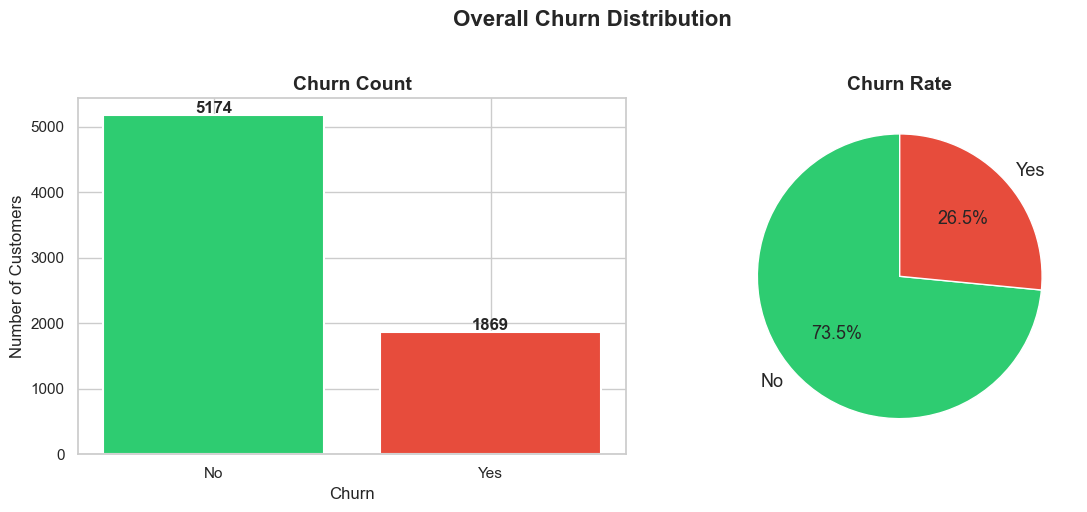


📌 Churn Rate: 26.5%


In [5]:
churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 13})
axes[1].set_title('Churn Rate', fontsize=14, fontweight='bold')

plt.suptitle('Overall Churn Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/churn_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\n📌 Churn Rate: {churn_counts['Yes'] / len(df) * 100:.1f}%")

## 3. Contract Type vs Churn — Top Churn Driver #1

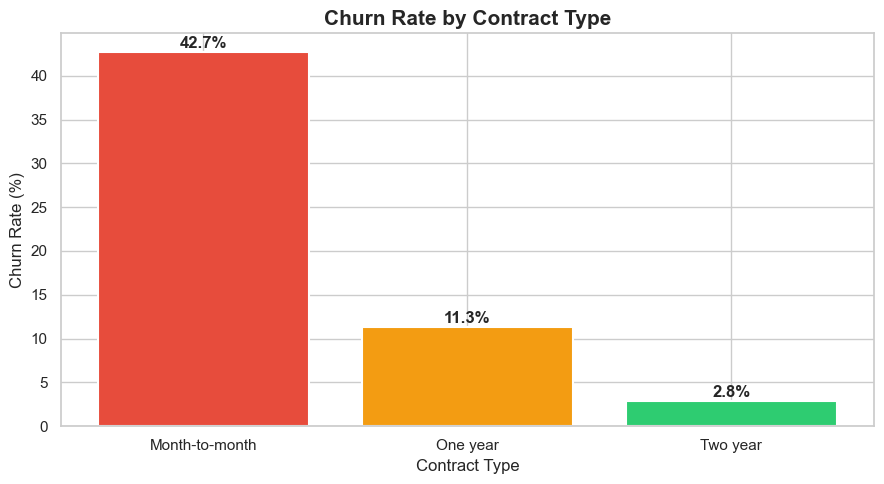

📌 Insight: Month-to-month customers churn at 3-4x the rate of long-term contract customers.


In [6]:
contract_churn = df.groupby('Contract')['Churn_Binary'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(9, 5))
bars = plt.bar(contract_churn.index, contract_churn.values,
               color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white', linewidth=1.5)
plt.title('Churn Rate by Contract Type', fontsize=15, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
for bar, val in zip(bars, contract_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../data/contract_churn.png', bbox_inches='tight', dpi=150)
plt.show()

print("📌 Insight: Month-to-month customers churn at 3-4x the rate of long-term contract customers.")

## 4. Tenure vs Churn — Top Churn Driver #2

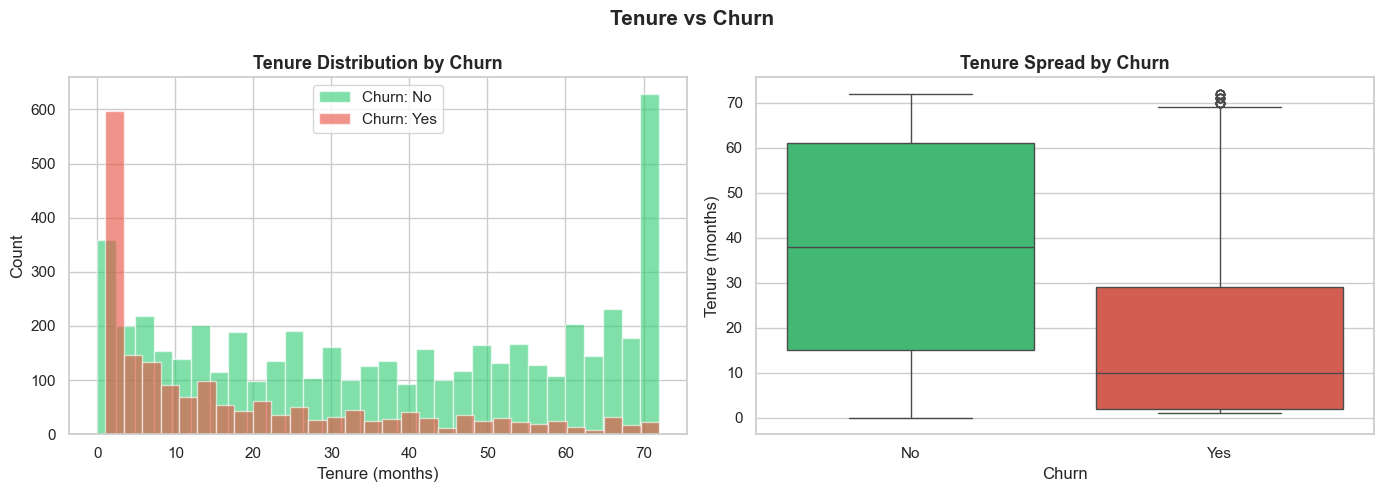

📌 Median tenure — Churned: 10.0 months | Stayed: 38.0 months
📌 Insight: Customers who churn leave early — most within the first 10 months.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for label, color in zip(['No', 'Yes'], ['#2ecc71', '#e74c3c']):
    subset = df[df['Churn'] == label]['tenure']
    axes[0].hist(subset, bins=30, alpha=0.6, label=f'Churn: {label}', color=color, edgecolor='white')
axes[0].set_title('Tenure Distribution by Churn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
sns.boxplot(data=df, x='Churn', y='tenure', palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, ax=axes[1])
axes[1].set_title('Tenure Spread by Churn', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Tenure (months)')

plt.suptitle('Tenure vs Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/tenure_churn.png', bbox_inches='tight', dpi=150)
plt.show()

churned_tenure = df[df['Churn'] == 'Yes']['tenure'].median()
stayed_tenure = df[df['Churn'] == 'No']['tenure'].median()
print(f"📌 Median tenure — Churned: {churned_tenure} months | Stayed: {stayed_tenure} months")
print("📌 Insight: Customers who churn leave early — most within the first 10 months.")

## 5. Monthly Charges vs Churn — Top Churn Driver #3

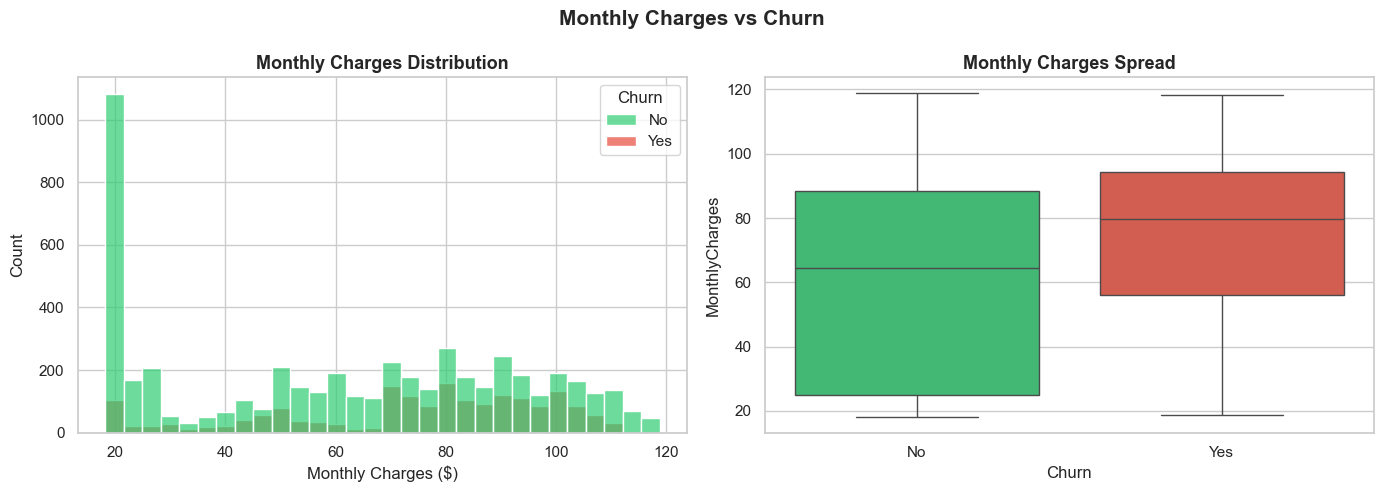

📌 Avg monthly charge — Churned: $74.44 | Stayed: $61.27
📌 Insight: High monthly charges strongly correlate with churn — price sensitivity is real.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='MonthlyCharges', hue='Churn',
             palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, bins=30, ax=axes[0], alpha=0.7)
axes[0].set_title('Monthly Charges Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Monthly Charges ($)')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges',
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, ax=axes[1])
axes[1].set_title('Monthly Charges Spread', fontsize=13, fontweight='bold')

plt.suptitle('Monthly Charges vs Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/charges_churn.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"📌 Avg monthly charge — Churned: ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.2f} | Stayed: ${df[df['Churn']=='No']['MonthlyCharges'].mean():.2f}")
print("📌 Insight: High monthly charges strongly correlate with churn — price sensitivity is real.")

## 6. Internet & Support Services vs Churn

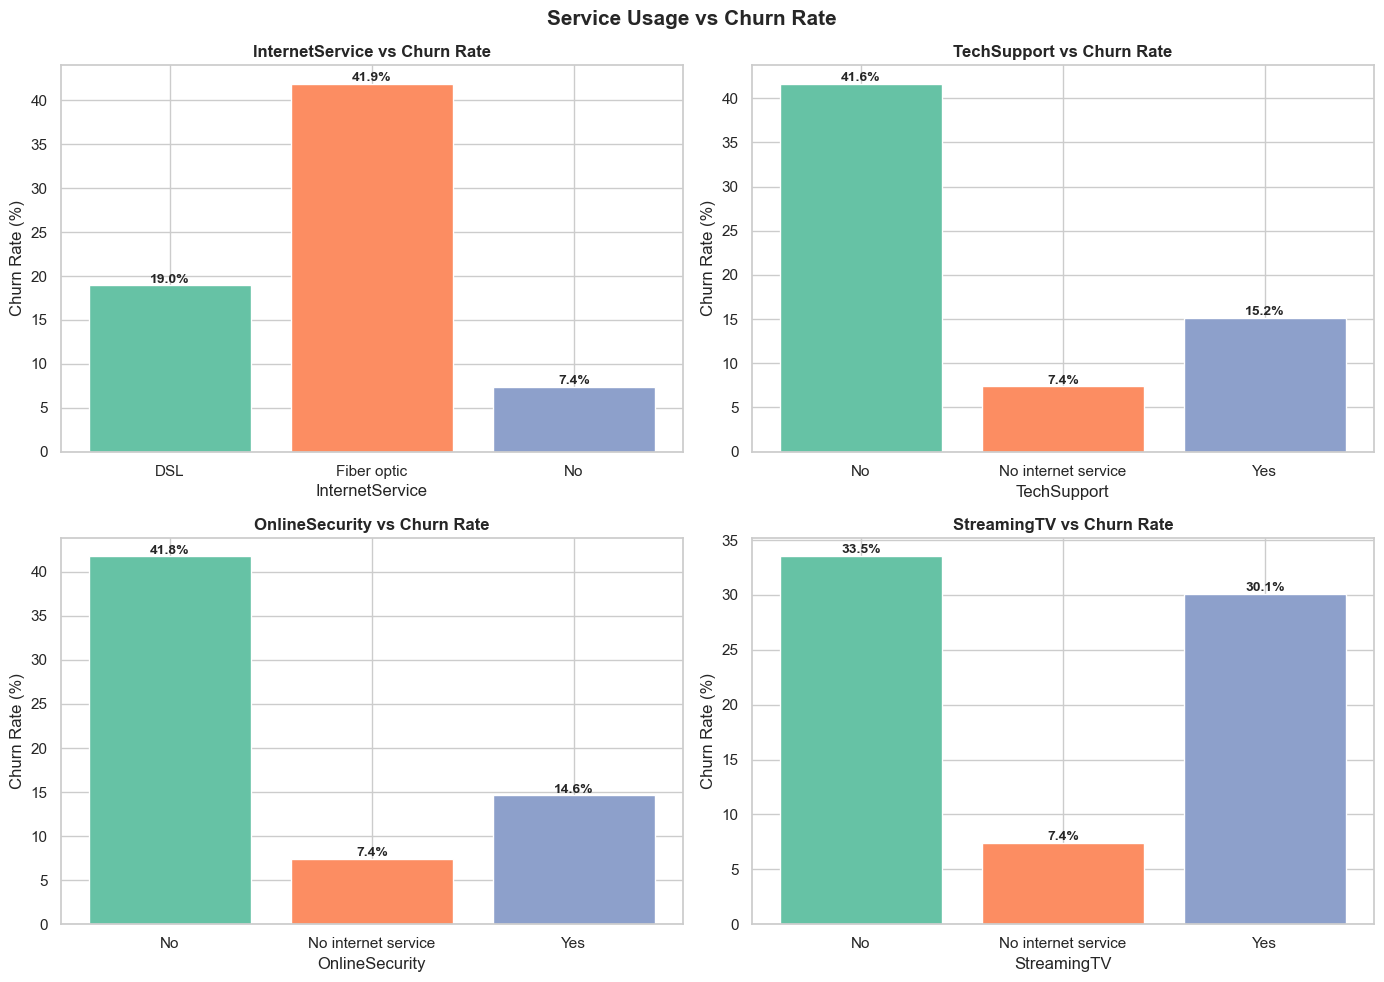

In [9]:
services = ['InternetService', 'TechSupport', 'OnlineSecurity', 'StreamingTV']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(services):
    churn_rate = df.groupby(col)['Churn_Binary'].mean() * 100
    bars = axes[i].bar(churn_rate.index, churn_rate.values,
                       color=sns.color_palette("Set2", len(churn_rate)), edgecolor='white')
    axes[i].set_title(f'{col} vs Churn Rate', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xlabel(col)
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Service Usage vs Churn Rate', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/services_churn.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Correlation Heatmap

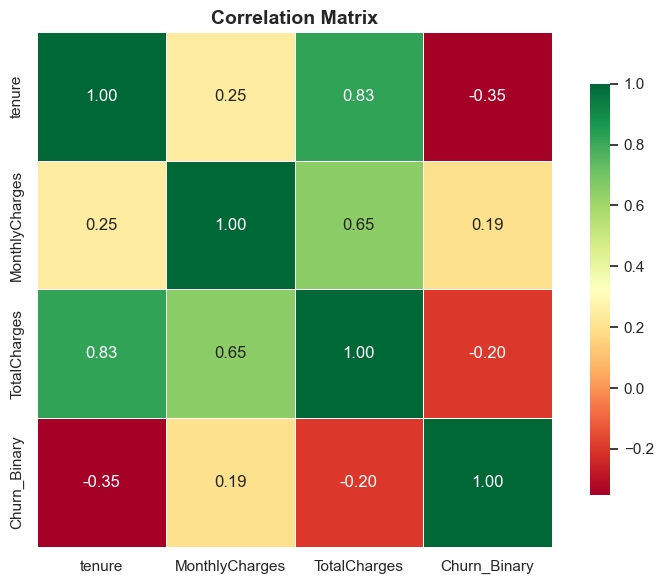

In [10]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Binary']
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

## 8. 🔑 Key Findings

| # | Finding | Business Impact |
|---|---------|----------------|
| 1 | **Month-to-month contracts** have 3–4x higher churn rate than annual contracts | Push customers toward longer contracts with discounts |
| 2 | **Most churn happens in the first 10 months** — median churned tenure is ~10 months vs ~38 for retained | Invest heavily in onboarding and early engagement |
| 3 | **High monthly charges** strongly correlate with churn | Introduce retention pricing or loyalty discounts for high-paying customers |
| 4 | **Customers without TechSupport or OnlineSecurity** churn significantly more | Bundle these services or offer free trials to at-risk customers |

> **Next:** SQL Analysis → `02_SQL_Analysis.ipynb`